In [1]:
import sqlite3

# Connect to database
conn = sqlite3.connect("supply_chain.db")
cursor = conn.cursor()

# Create table if not exists
cursor.execute("""
CREATE TABLE IF NOT EXISTS decisions (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    actions TEXT,
    predicted_cost REAL,
    predicted_time_reduction REAL,
    actual_cost REAL,
    actual_time_reduction REAL,
    roi REAL
)
""")

conn.commit()

In [2]:
import random

def simulate_actuals(pred_cost, pred_time):
    """
    Simulate real-world outcome (slight variation)
    """
    actual_cost = pred_cost + random.uniform(-20, 50)
    actual_time = pred_time + random.uniform(-5, 10)
    return actual_cost, actual_time

In [3]:
def store_decision(actions, pred_cost, pred_time):
    actual_cost, actual_time = simulate_actuals(pred_cost, pred_time)

    # ROI formula
    roi = actual_time - actual_cost * 0.1   # simple business logic

    conn = sqlite3.connect("supply_chain.db")
    cursor = conn.cursor()

    cursor.execute("""
    INSERT INTO decisions (
        actions, predicted_cost, predicted_time_reduction,
        actual_cost, actual_time_reduction, roi
    )
    VALUES (?, ?, ?, ?, ?, ?)
    """, (str(actions), pred_cost, pred_time, actual_cost, actual_time, roi))

    conn.commit()
    conn.close()

    print("✅ Decision stored with actual outcome!")

In [4]:
def evaluate_decisions():
    conn = sqlite3.connect("supply_chain.db")
    cursor = conn.cursor()

    cursor.execute("SELECT * FROM decisions")
    rows = cursor.fetchall()

    print("\n📊 Evaluation Results:\n")

    for row in rows:
        id, actions, p_cost, p_time, a_cost, a_time, roi = row

        cost_diff = a_cost - p_cost
        time_diff = a_time - p_time

        print(f"Decision ID: {id}")
        print(f"Actions: {actions}")
        print(f"Predicted Cost: {p_cost:.2f} | Actual Cost: {a_cost:.2f}")
        print(f"Predicted Time: {p_time:.2f} | Actual Time: {a_time:.2f}")
        print(f"Cost Difference: {cost_diff:.2f}")
        print(f"Time Difference: {time_diff:.2f}")
        print(f"ROI: {roi:.2f}")
        print("-" * 40)

    conn.close()

In [5]:
def decision_roi_analysis():
    conn = sqlite3.connect("supply_chain.db")
    cursor = conn.cursor()

    cursor.execute("SELECT roi FROM decisions")
    rois = cursor.fetchall()

    rois = [r[0] for r in rois]

    if len(rois) == 0:
        print("No data available.")
        return

    positive = len([r for r in rois if r > 0])
    total = len(rois)

    success_rate = (positive / total) * 100
    avg_roi = sum(rois) / total

    print("\n📈 Decision ROI Analytics:")
    print(f"Total Decisions: {total}")
    print(f"Positive ROI Decisions: {positive}")
    print(f"Success Rate: {success_rate:.2f}%")
    print(f"Average ROI: {avg_roi:.2f}")

    conn.close()

In [6]:
import matplotlib.pyplot as plt

def plot_roi():
    conn = sqlite3.connect("supply_chain.db")
    cursor = conn.cursor()

    cursor.execute("SELECT roi FROM decisions")
    rois = [r[0] for r in cursor.fetchall()]

    conn.close()

    if len(rois) == 0:
        print("No data to plot.")
        return

    plt.figure()
    plt.plot(rois, marker='o')
    plt.title("Decision ROI Over Time")
    plt.xlabel("Decision Number")
    plt.ylabel("ROI")
    plt.grid()
    plt.show()

✅ Decision stored with actual outcome!

📊 Evaluation Results:

Decision ID: 1
Actions: [0, 2]
Predicted Cost: 250.00 | Actual Cost: 267.39
Predicted Time: 25.00 | Actual Time: 20.38
Cost Difference: 17.39
Time Difference: -4.62
ROI: -6.36
----------------------------------------

📈 Decision ROI Analytics:
Total Decisions: 1
Positive ROI Decisions: 0
Success Rate: 0.00%
Average ROI: -6.36


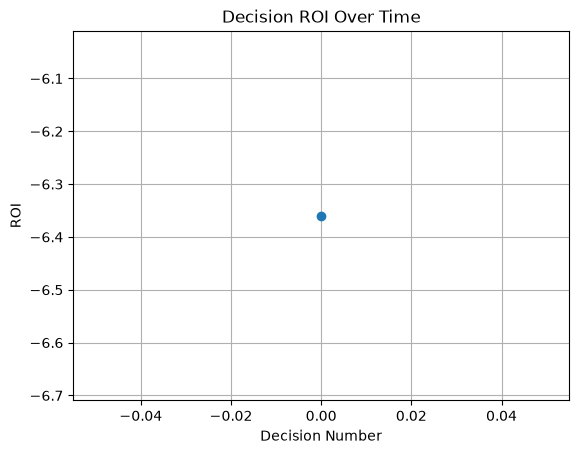

In [7]:
# Example decision from Week 2
actions = [0, 2]
predicted_cost = 250
predicted_time_reduction = 25

# Store decision with simulated actuals
store_decision(actions, predicted_cost, predicted_time_reduction)

# Evaluate all decisions
evaluate_decisions()

# ROI analytics
decision_roi_analysis()

# Plot graph
plot_roi()

In [8]:
for i in range(5):
    store_decision([0,2], 250, 25)

✅ Decision stored with actual outcome!
✅ Decision stored with actual outcome!
✅ Decision stored with actual outcome!
✅ Decision stored with actual outcome!
✅ Decision stored with actual outcome!


In [9]:
evaluate_decisions()


📊 Evaluation Results:

Decision ID: 1
Actions: [0, 2]
Predicted Cost: 250.00 | Actual Cost: 267.39
Predicted Time: 25.00 | Actual Time: 20.38
Cost Difference: 17.39
Time Difference: -4.62
ROI: -6.36
----------------------------------------
Decision ID: 2
Actions: [0, 2]
Predicted Cost: 250.00 | Actual Cost: 285.94
Predicted Time: 25.00 | Actual Time: 33.82
Cost Difference: 35.94
Time Difference: 8.82
ROI: 5.23
----------------------------------------
Decision ID: 3
Actions: [0, 2]
Predicted Cost: 250.00 | Actual Cost: 244.09
Predicted Time: 25.00 | Actual Time: 27.97
Cost Difference: -5.91
Time Difference: 2.97
ROI: 3.56
----------------------------------------
Decision ID: 4
Actions: [0, 2]
Predicted Cost: 250.00 | Actual Cost: 238.20
Predicted Time: 25.00 | Actual Time: 23.72
Cost Difference: -11.80
Time Difference: -1.28
ROI: -0.10
----------------------------------------
Decision ID: 5
Actions: [0, 2]
Predicted Cost: 250.00 | Actual Cost: 251.21
Predicted Time: 25.00 | Actual Time

In [10]:
decision_roi_analysis()


📈 Decision ROI Analytics:
Total Decisions: 6
Positive ROI Decisions: 3
Success Rate: 50.00%
Average ROI: 0.23


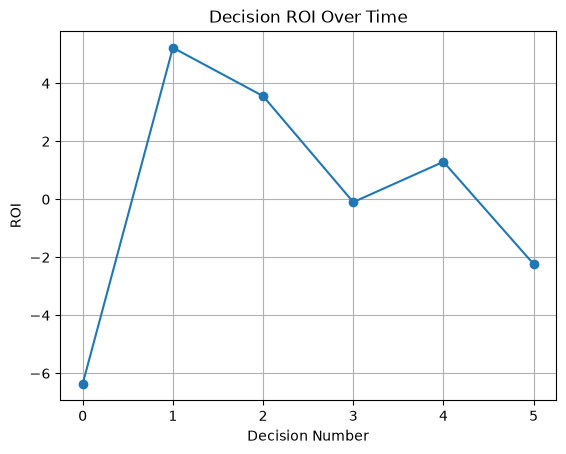

In [11]:
plot_roi()